<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification" / Mai 20-21, 2026<br> 
v1.1  - CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<div class="alert alert-block alert-danger">
<span style="color:brown;font-family:arial;font-size:normal">
     It is important to define a <span style="font-weight:bold;">Python Virtual Environment</span> (PVE) for each Python project: 
     a PVE allows you to control the versions of the Python interpreter and “sensitive” modules (tensorflow...) for each project.<br>

- a KAGGLE session can serve as a PVE,
- or if on a local machine, use the `uv` manager to create a PVE and run the notenbook with `uv run jupyter lab` to ensure it uses the PVE of the projet.

<span style="color:maroon; font-family:arial;font-size:1.2cm; font-weight:bold">
    The question of Reproducibility<br>
    in Supervised Learning
</span>

<span style="color:maroon; font-family:arial; font-size:0.6cm;">
    In this notebook we use a very simple neural network model to focus on<br>
    the reproducibility of training the model.
</span>

# Preliminaries

## Configure KAGGLE environment (if needed)

Run the next cell if you run a remote KAGGLE jupyter notebook to configure your kaggle environment.<br>
If you run a local jupyter notebook it wil do nothing.

In [1]:
import os, sys
from pathlib import Path

if 'kaggle' in Path.cwd().as_posix():
    KAGGLE = True
    print(f'Notebook running on KAGGLE')
else:
    KAGGLE = False
    print(f'Notebook not running on KAGGLE')

if KAGGLE:
    #
    # Add the path to the <utils> directory to the sys.path list:
    #
    paths = list(Path('/kaggle').rglob('utils'))
    if len(paths) == 0:
        print('\tNo <utils> directory found in your workspace, sorry.')
    else:
        util_path = paths[0].parent.as_posix()
        sys.path.append(util_path)
        print(f'\t<{util_path}> added to sys.path.')
    
    #
    # Create a link <img> to the image directory of the dataset éDL img"
    #
    img_dataset_path = Path('/kaggle/input/datasets/jlcharles/dl-img')
    link_to_img_dir  = Path.cwd() / 'img'
    if not link_to_img_dir.is_symlink(): 
        link_to_img_dir.symlink_to(img_dataset_path)
    print(f'\tlink <{link_to_img_dir}> to <{img_dataset_path}> OK')

    #
    # import the GPUtil module
    #
    try:
        os.system('pip install GPUtil')
    except OSError as e:
        print("Execution failed:", e, file=sys.stderr)

Notebook not running on KAGGLE


## Import the Python modules

In [2]:
import os
# suppress tensorflow verbose warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# Custom modules:
from utils.tools import elapsed_time_since, cpu_gpu, plot_loss_accuracy

E0000 00:00:1776802441.949933  649799 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776802441.954929  649799 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776802441.966604  649799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776802441.966619  649799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776802441.966620  649799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776802441.966621  649799 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.12.12
tensorflow: 2.19.0 with keras 3.14.0
numpy     : 2.1.3
OpenCV    : 4.13.0


## Set global behaviour

In [4]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

## Check wether GPU is available for tensorflow or not:

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
        # configure tensorflow to dynamically allocate GPU memory as needed:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found, only CPU.")

No GPU found, only CPU.


## Create the `models` directory

In [6]:
print(f'{"WORKING DIRECTORY":20s}: {Path.cwd()}')
model_path = Path("./models")
model_path.mkdir(exist_ok=True)
print(f'{"MODELS DIRECTORY":20s}: {model_path.absolute().as_posix()}')

WORKING DIRECTORY   : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks
MODELS DIRECTORY    : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks/models


# 1 - Prepare the MNIST dataset (images and labels)

## 1.1 Load the MNIST dataset

We use the keras `load_data` function to load the data from the MNIST 
(see [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)):<br>
- `train_img`, `train_lab` are the training images and labels,
- `valid_img`, `valid_lab` are the validation images and labels.

In [7]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

Let's check the `shape` and `dtype` attributes of the numpy arrays:

In [8]:
print(f"train_img.shape: {train_img.shape}, dtype: {train_img.dtype}")
print(f"train_lab.shape: {train_lab.shape}, dtype: {train_lab.dtype}")
print(f"valid_img.shape: {valid_img.shape}, dtype: {valid_img.dtype}")
print(f"lab_vaild.shape: {valid_lab.shape}, dtype: {valid_lab.dtype}")

train_img.shape: (60000, 28, 28), dtype: uint8
train_lab.shape: (60000,), dtype: uint8
valid_img.shape: (10000, 28, 28), dtype: uint8
lab_vaild.shape: (10000,), dtype: uint8


<span style="color:maroon; font-family:arial; font-size:15pt;">
    To avoid excessive computation time, we take only 1000 images & labels in the training dataset and 200 images & labels in the validation dataset.</span>
</span>

In [9]:
train_img = train_img[:1000]
valid_img = valid_img[:200]

train_lab = train_lab[:1000]
valid_lab = valid_lab[:200]

Let's check the sizes of the 3 datasets:

In [10]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')

train:  (1000, 28, 28)
valid:  (200, 28, 28)


## 1.2 Visualize of images and labels:

The local module `utils.tools` defines the `plot_images` function which can be used to display a grid of MNIST images.<br>
Let's plot a grid of images 3 x 10 beginning with the 600th image:

In [11]:
from utils.tools import plot_images
help(plot_images)

Help on function plot_images in module utils.tools:

plot_images(image_array: numpy.ndarray, R: int, C: int, r: int = 0, figsize: tuple = None, label_array: numpy.ndarray = None, reverse: bool = False, ret: bool = False)
    Plot the images from image_array on a R x C grid, starting at image rank r.
    Arguments:
       image_array: an array of images
       R: the number of rows
       C: the number of columns
       r: the starting rank in the array image_array (default: 0)
       figsize: the sise of the display (default: (C//2+1, R//2+1))
       label_array: an optional array of labels to give the imshow title
       reverse: wether to reverse video the image or not (default: False)
       ret: wether to return the fig or not (useful for marimo)



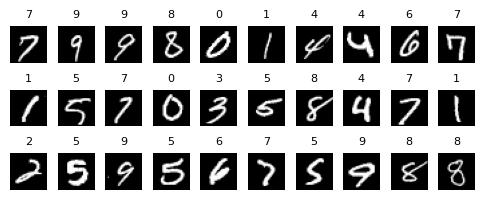

In [12]:
plot_images(train_img, R=3, C=10, r=599, label_array=train_lab)

## 1.4 Check the quality of the dataset

Unbalanced classes can create some difficulties to train and evaluate the model: we verify that the proportion of digits remains homogenous in the 3 datasets thanks to the `plot_proportion_bar` of the `utils.tools` module:

In [13]:
from utils.tools import plot_proportion_bar
help(plot_proportion_bar)

Help on function plot_proportion_bar in module utils.tools:

plot_proportion_bar(proportions: dict, class_rank, figsize=(6, 4), message='', ret: bool = False)
    To plot propotion of classes in different datasets.
    proportion: the dictionnary {<dataset name>: <[number of class in teh dataset]>}



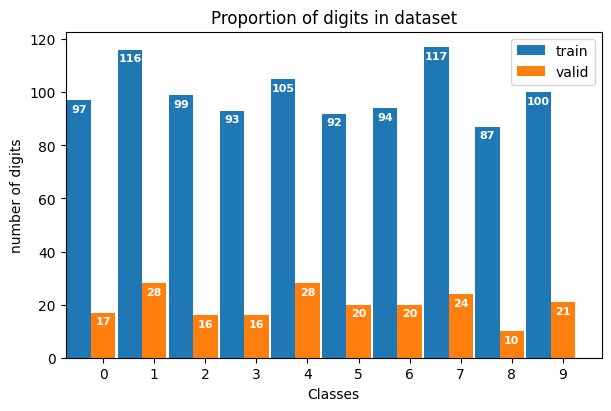

In [14]:
from utils.tools import plot_proportion_bar
prop = {}
prop['train'] = [ (train_lab == i).sum() for i in range(10)]
prop['valid']  = [ (valid_lab  == i).sum() for i in range(10)]
plot_proportion_bar(prop, range(10))

## 1.5 -  Define important parameters

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are recovered from the data set:
- with the shape attribute of the `train_img` and `test_im` arrays
- with the size attribute of the first training image for example


In [15]:
NB_TRAIN_IMG = train_img.shape[0]  # number of training images
NB_VALID_IMG = valid_img.shape[0]  # number of validation images 
NB_PIXEL     = train_img[0].size   # number of elements (pixels) of the firts training image: 
NB_CLASS     = len(set(train_lab)) # number of classes:

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

1000 training images, 200 validation images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


# 2 - Process input data

Two treatments must be applied to the data from the MNIST database:
- **on images**: transform the matrices of  28$\,\times\,$28 pixels (`uint8`integers) into **normalized** vectors $(V_i)_{i=0..783}$ of 784 real values $V_i$ with $ 0 \leqslant V_i \leqslant 1$;
- **on labels**: transform scalar numbers into *one-hot* vectors.

## 2.1 - Transform input matrices into normalized vectors

We define the arrays `x_train`, `x_valid` and `x_test` containing the matrices of the arrays `train_img`, `valid_img` and `test_img` *flattened* as normalized vectors (values between 0 and 1):

In [16]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')

train: (1000, 784), min: 0.0, max: 1.0
valid: (200, 784), min: 0.0, max: 1.0


## 2.2 - *one-hot* encoding of labels

We use the **keras** `to_categorical` function (see [tf.keras.utils.to_categorical](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical)) to define the `y_train` and `y_valid` arrays containing the *hot-one* encoded version of `lab_train` and `lab_valid`:

In [17]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)

Let's check the first 10 values of the `lab_train` and `y_train` arrays:

In [18]:
print(train_lab[:10])
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


# 3 - Build the Dense Neural Network (DNN)

 We build a simple dense network to classify MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores,<br>
 but we just want want a simple model easy to understand with short training computation time.<br><br>
We buildthis naive **dense network**:
- an **input layer** of 784 values (the pixels of the MNIST 28 $\times$ 28 images flattened in the form of a vector of 784 normalized `float` numbers),
- a **hidden layer** of 100 neurons using the `relu` activation function,
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function adapted to classification problems .

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/Simple-DNN.png" alt="Simple-DNN.png" style="width:900px;"><br>
     [image credit: JLC]

For the sake of convenience we défine a parameterized function to build the NN: 

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

def build_DNN(nb_input, nb_neuron, nb_class, seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(nb_input,), name='input'))               # INPUT layer
    model.add(Dense(nb_neuron, activation='relu', name='c1'))       # First hidden layer
    model.add(Dense(nb_class, activation='softmax', name='output')) # OUTPUT layer
   
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    
    if name: model.name = name
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [20]:
NB_NEURON = NB_PIXEL

In [21]:
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, name='simple DNN')
model.summary()

Model: "simple DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

# 4 - Elementary tests of the reproducibility of the model training...

The training of a neural network is a stochastic process: perfect reproducibility of the training may be difficult to achieve...<br><br>
To highlight the question of reproducibility we run a simple short experiment: $\leadsto$ run a loop where the model is built without setting the seed, trained and evaluated once (_epochs=1_) at each lap loop.

### 4.1 Build the model no SEED at each loop lap $\leadsto$ training not reproducible

Results obtained on PC tower with CPU Intel Xeon @ 3.5 GHz and a Quadro RTX8000 GPU
<div class="frame">
   <img style="border:1px solid black; width:820px;" src="img/MNIST_DNN_noseed_1epoch_batch32-XEON.png" alt="MNIST_DNN_noseed_1epoch_batch32-XEON.png"><br>
</div

Run the cell bellow on your laptop:

In [22]:
print(cpu_gpu())
for _ in range(5):
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS)  # Build a new model without setting seed
    model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
32/32 - 1s - 30ms/step - accuracy: 0.7140 - loss: 1.0206 - val_accuracy: 0.8350 - val_loss: 0.5122
32/32 - 1s - 27ms/step - accuracy: 0.7270 - loss: 1.0011 - val_accuracy: 0.7900 - val_loss: 0.6041
32/32 - 1s - 27ms/step - accuracy: 0.6970 - loss: 1.0363 - val_accuracy: 0.8550 - val_loss: 0.5318
32/32 - 1s - 33ms/step - accuracy: 0.7170 - loss: 1.0051 - val_accuracy: 0.8250 - val_loss: 0.4959
32/32 - 1s - 28ms/step - accuracy: 0.7250 - loss: 1.0056 - val_accuracy: 0.8150 - val_loss: 0.5379


We repeat 5 times the first epoch of the training: the training metrics are close together but not exactly the same.<br>
This is particularly problematic for the `val_loss` metric used to evaluate the training after each epoch $\leadsto$ the training is not reproducible.

### 4.2 Build a model no SEED once, reload the model weights at each loop lap $\leadsto$ training not reproducible

We save the weights of a model built without setting the seed:

In [23]:
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS)
model.save_weights('models/DNN_noseed.weights.h5')

Results obtained on PC tower with CPU Intel Xeon @ 3.5 GHz and a Quadro RTX8000 GPU
<div class="frame">
   <img style="border:1px solid black; width:860px;" 
       src="img/MNIST_DNN_noseed_relod_1epoch_batch32-XEON.png" alt="MNIST_DNN_noseed_relod_1epoch_batch32-XEON.png"><br>
</div

Run the cell bellow on your laptop:

In [24]:
print(cpu_gpu())
for _ in range(5):
    model.load_weights('models/DNN_noseed.weights.h5') # reload the inital model weights
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
32/32 - 1s - 26ms/step - accuracy: 0.7400 - loss: 0.9616 - val_accuracy: 0.8650 - val_loss: 0.4623


/home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 - 0s - 8ms/step - accuracy: 0.6910 - loss: 1.0758 - val_accuracy: 0.8750 - val_loss: 0.4576
32/32 - 0s - 10ms/step - accuracy: 0.6920 - loss: 1.0709 - val_accuracy: 0.8500 - val_loss: 0.5019
32/32 - 0s - 10ms/step - accuracy: 0.7220 - loss: 1.0458 - val_accuracy: 0.8450 - val_loss: 0.4674
32/32 - 0s - 12ms/step - accuracy: 0.7080 - loss: 1.0656 - val_accuracy: 0.8550 - val_loss: 0.4963


The training is still non-reproducible.

### 4.3 Build the model with SEED at each loop lap: training perfectly reproducible

Results obtained on PC tower with CPU Intel Xeon @ 3.5 GHz and a Quadro RTX8000 GPU
<div class="frame">
   <img style="border:1px solid black; width:870px;" 
       src="img/MNIST_DNN_seed_1epoch_batch32-XEON.png" alt="MNIST_DNN_seed_1epoch_batch32-XEON.png"><br>
</div

In [25]:
print(cpu_gpu())
for _ in range(5):
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=1234)  # Build a new model with seed set
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
32/32 - 1s - 35ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 30ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 28ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 29ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 29ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894


If we set the seed when creating the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible &#128526;.

### 4.4 Build the model with SEED once, load the model structure & initial weights at each loop lap: training perfectly reproducible

In [26]:
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=1234)
model.save('models/DNN_seed1234.keras')

Results obtained on PC tower with CPU Intel Xeon @ 3.5 GHz and a Quadro RTX8000 GPU
<div class="frame">
   <img style="border:1px solid black; width:870px;" 
       src="img/MNIST_DNN_seed_reload_1epoch_batch32-XEON.png" alt=""MNIST_DNN_seed_reload_1epoch_batch32-XEON.png><br>
</div

Run the cell bellow on your laptop:

In [27]:
print(cpu_gpu())
for _ in range(5):
    model = tf.keras.models.load_model('models/DNN_seed1234.keras') # reload the model structure & weights 
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
32/32 - 1s - 25ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 25ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 25ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 25ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894
32/32 - 1s - 25ms/step - accuracy: 0.7170 - loss: 0.9627 - val_accuracy: 0.8650 - val_loss: 0.4894


If we load the structure and the weights of the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible  &#128526;.

<span style="color:maroon; font-family:arial; font-size:15pt;">
Solution to ensure the reproducibility of the training:<br>
$\leadsto$ <b>set the seed</b> at the model creation (and everywhere else where required)<br>
$\leadsto$ <b>reload the model structure and weights</b> with the <b>tf.keras.models.load_model</b> function<br><br>
</spawn>

# 5 - Adressing the reproducibility of the model training...

## 5.1 - Run several trainings with a new model (no SEED) at each iteration $\leadsto$ not reproducible

In [28]:
H, t0 = [], time()

for i in range(6):
    print(f"Loop #{i+1}")
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS)                # build a new network, no SEED given
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=15,        # the total number of successive trainings
                     batch_size=32,    # split the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=0)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   

Loop #1
Loop #2
Loop #3
Loop #4
Loop #5
Loop #6
 Total Train Elapsed time 25s -> 00:00:25


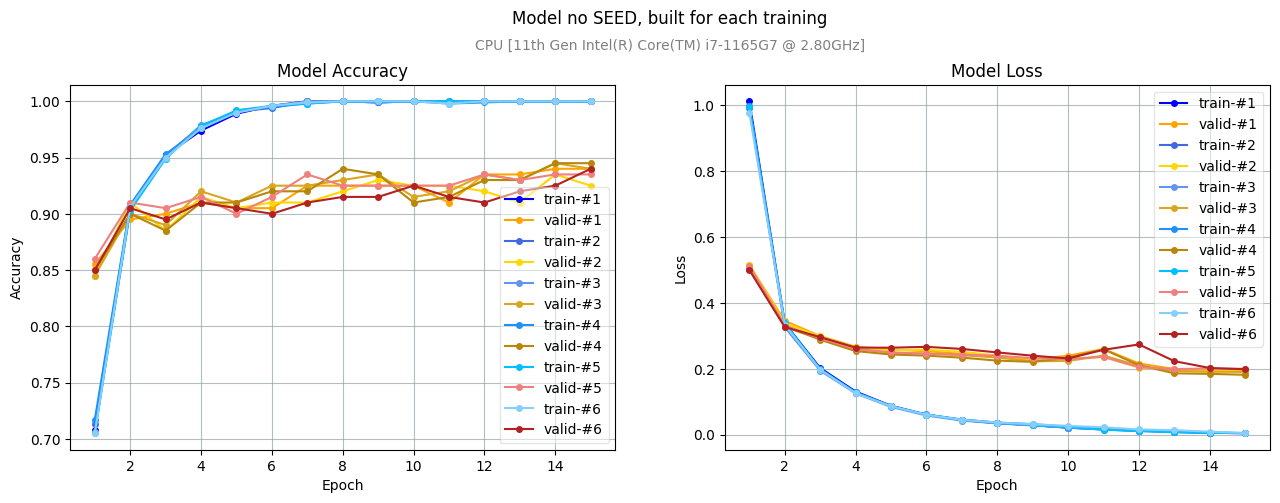

In [29]:
plot_loss_accuracy(H, message='Model no SEED, built for each training', single_legend=False)

Let's zoom a bit on the validation accuracy & loss:

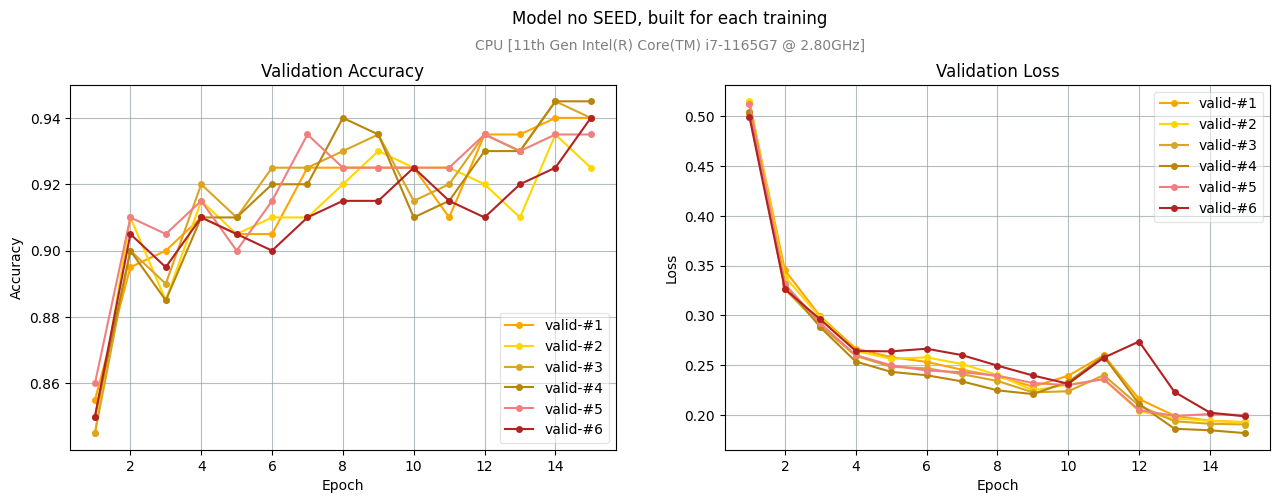

In [30]:
plot_loss_accuracy(H, message='Model no SEED, built for each training', plot_train=False, single_legend=False)

The `val_loss` and `val_accuracy` differ at each of the training.<br>
It is a problem when we train the model with a _callback_ like __early stoppping__ : the training will stop at a different epoch if we run the training many times.

## 5.2 - New model with SEED at each loop lap: $\leadsto$ reproducible

In [31]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
    
    # build a new network/
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=1234)            # build a new network with a fixed SEED
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=10,        # the total number of successive trainings
                     batch_size=32,    # split of the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=0)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')

training #1
training #2
training #3
training #4
training #5
 Total Train Elapsed time 15s -> 00:00:15


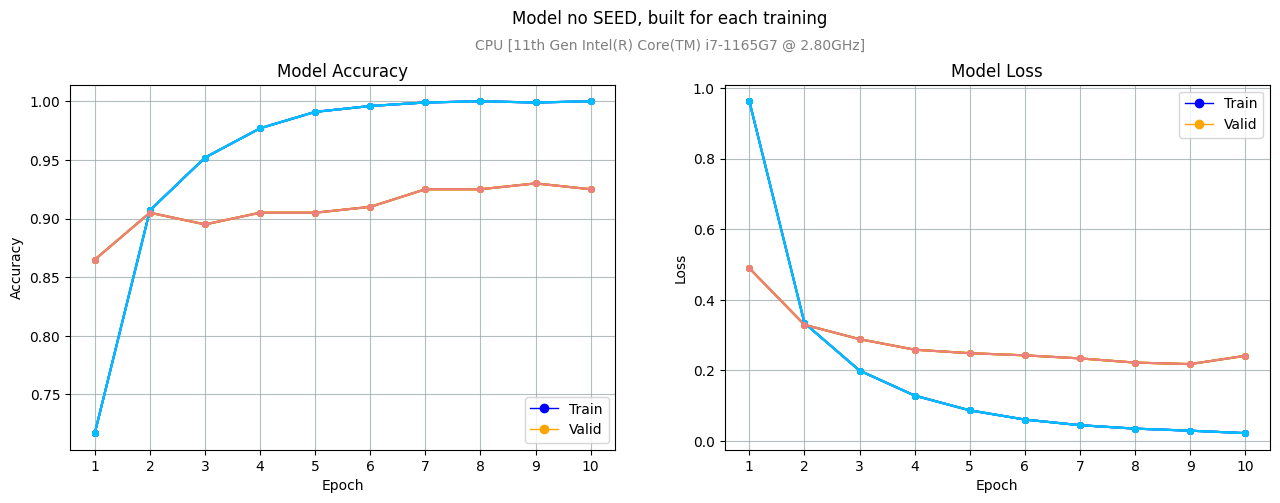

In [32]:
plot_loss_accuracy(H, message='Model no SEED, built for each training', single_legend=True)

Let's zoom a bit on the validation accuracy & loss:

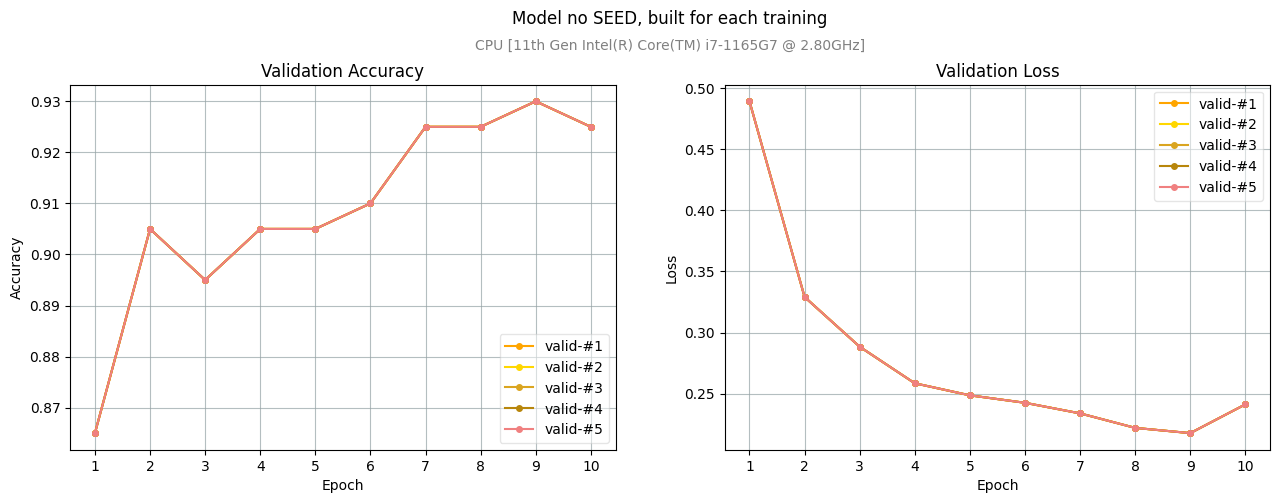

In [33]:
plot_loss_accuracy(H, message='Model no SEED, built for each training', plot_train=False, single_legend=False)

$\leadsto$ the repoducibility is perfect &#128526;

## 5.3 - Reloading the model structure & weights with SEED at each loop lap $\leadsto$ reproducible

In [37]:
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=1234)
model.save('models/DNN_seed-1234.keras')

In [38]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
                
    # reload the structure of the NN and its initial state 
    model = tf.keras.models.load_model('models/DNN_seed-1234.keras') 
    
    # Deterministic tensorflow training: 
    tf.keras.utils.set_random_seed(1234) 
    tf.config.experimental.enable_op_determinism() 

    # train the network
    hist = model.fit(x_train, y_train, 
                     epochs=10, 
                     batch_size=32,
                     validation_data=(x_valid, y_valid), 
                     verbose=0)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   

training #1
training #2
training #3
training #4
training #5
 Total Train Elapsed time 15s -> 00:00:15


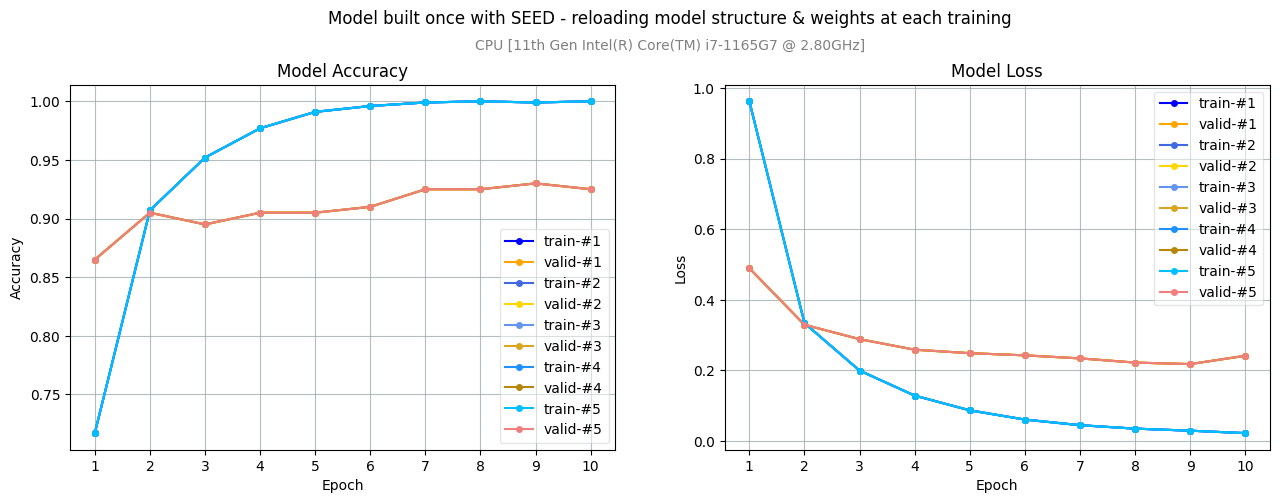

In [39]:
plot_loss_accuracy(H, message='Model built once with SEED - reloading model structure & weights at each training', single_legend=False)

Let's zoom a bit on the validation accuracy & loss:

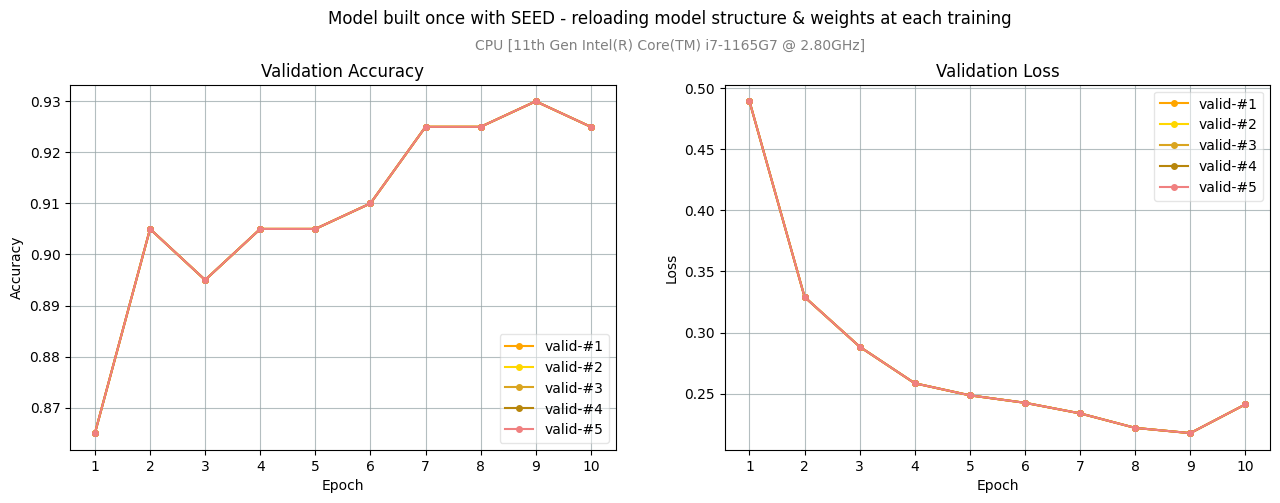

In [40]:
plot_loss_accuracy(H, message='Model built once with SEED - reloading model structure & weights at each training', plot_train=False, single_legend=False)

# Conclusion

<span style="color:maroon; font-family:arial; font-size:12pt;">

What you have learned in this notebook:
<ul>
  <li>How to load the MNIST databank with the <b>tensorflow</b> module</li>
  <li>How to pre-process the input dataset before the training</li>
  <li>Why are there issues to get reproducible trainings and what are the solutions</li>
</ul>

$\leadsto$ in the next notebook <i>02_Evaluation_Strategies.ipynb</i>, you will learn how to reliably evaluate the performance of a trained model.
</span>    